In [ ]:
# Cell 1: Imports
import os
import shutil
import random
import matplotlib.pyplot as plt

In [ ]:
print(os.listdir(r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data"))

['dataset', 'processed']


In [ ]:
# Cell 2: Define Paths (FIXED)
SOURCE_DIR = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\dataset"
DEST_DIR   = r"C:\Users\anind\OneDrive\Desktop\DL_Proj_Face_Emotion\data\processed"

TRAIN_RATIO = 0.7
VAL_RATIO   = 0.2
TEST_RATIO  = 0.1

In [ ]:
import shutil

shutil.rmtree(DEST_DIR)
os.makedirs(DEST_DIR, exist_ok=True)

In [ ]:
# Cell 3: Split Dataset (GLOBAL SPLIT → 70/20/10)

import os
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(source, dest):
    all_files = []
    all_labels = []

    # Collect all files with labels
    for label in os.listdir(source):
        label_path = os.path.join(source, label)

        if not os.path.isdir(label_path):
            continue

        for f in os.listdir(label_path):
            all_files.append(os.path.join(label_path, f))
            all_labels.append(label)

    # First split → Train (70%) and Temp (30%)
    train_files, temp_files, train_labels, temp_labels = train_test_split(
        all_files, all_labels,
        test_size=(1 - TRAIN_RATIO),
        stratify=all_labels,
        random_state=42
    )

    # Compute adjusted ratio for second split
    test_ratio_adjusted = TEST_RATIO / (VAL_RATIO + TEST_RATIO)

    # Second split → Val (20%) and Test (10%)
    val_files, test_files, val_labels, test_labels = train_test_split(
        temp_files, temp_labels,
        test_size=test_ratio_adjusted,
        stratify=temp_labels,
        random_state=42
    )

    splits = {
        "train": (train_files, train_labels),
        "val": (val_files, val_labels),
        "test": (test_files, test_labels)
    }

    # Copy files into folders
    for split in splits:
        files, labels = splits[split]

        for f, label in zip(files, labels):
            split_path = os.path.join(dest, split, label)
            os.makedirs(split_path, exist_ok=True)

            dst = os.path.join(split_path, os.path.basename(f))
            shutil.copy(f, dst)

    print("Dataset Split Completed (Global Stratified)")

split_dataset(SOURCE_DIR, DEST_DIR)

Dataset Split Completed (Global Stratified)


In [ ]:
# Cell 4: Verify Split Counts

def count_images(base_dir):
    summary = {}

    for split in ["train", "val", "test"]:
        split_path = os.path.join(base_dir, split)
        total = 0

        for label in os.listdir(split_path):
            label_path = os.path.join(split_path, label)
            count = len(os.listdir(label_path))
            total += count

        summary[split] = total

    return summary

counts = count_images(DEST_DIR)

print("Split Summary:")
for k,v in counts.items():
    print(f"{k.upper()}: {v}")

Split Summary:
TRAIN: 15987
VAL: 4568
TEST: 2284


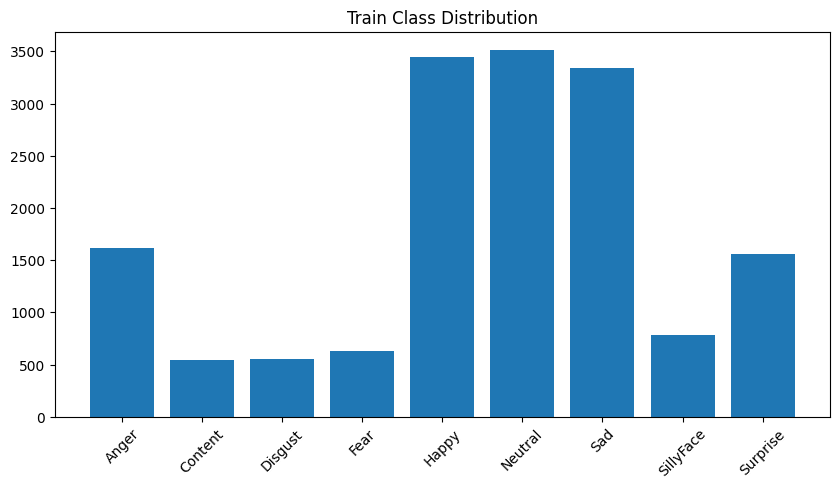

In [ ]:
# Cell 5: Class-wise Distribution (Train only)

train_path = os.path.join(DEST_DIR, "train")

class_counts = {}

for label in os.listdir(train_path):
    label_path = os.path.join(train_path, label)
    class_counts[label] = len(os.listdir(label_path))

plt.figure(figsize=(10,5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Train Class Distribution")
plt.show()